# Linear Regression Study — House Prices (SalePrice)

This notebook studies **linear regression** using the Kaggle *House Prices: Advanced Regression Techniques* dataset.

Goals:
1. Explore `SalePrice` and its relationship with key predictors.
2. Fit a **simple linear regression** (one feature) to build intuition.
3. Fit a **multiple linear regression** with several numeric features.
4. Compare with **regularized** variants (Ridge / Lasso).
5. Evaluate with train/test split, RMSE, R², and residual diagnostics.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)


## 1. Load the data

In [2]:
train = pd.read_csv("dataset/train.csv")
test = pd.read_csv("dataset/test.csv")

print(train.shape, test.shape)
train.head()


(1460, 81) (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. Explore `SalePrice`

In [3]:
train["SalePrice"].describe()


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

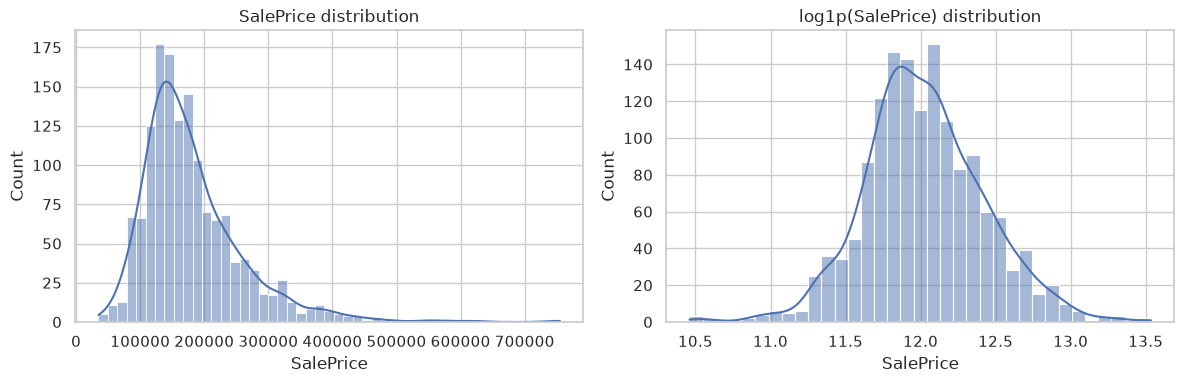

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(train["SalePrice"], kde=True, ax=axes[0])
axes[0].set_title("SalePrice distribution")

sns.histplot(np.log1p(train["SalePrice"]), kde=True, ax=axes[1])
axes[1].set_title("log1p(SalePrice) distribution")

plt.tight_layout()
plt.show()


`SalePrice` is right-skewed, which is typical for prices. A log transform makes it closer to normal —
useful later since linear regression assumes roughly normal, homoscedastic residuals.

## 3. Find features most correlated with SalePrice

In [5]:
numeric_cols = train.select_dtypes(include=[np.number]).columns
corr = train[numeric_cols].corr()["SalePrice"].sort_values(ascending=False)
corr.head(15)


SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

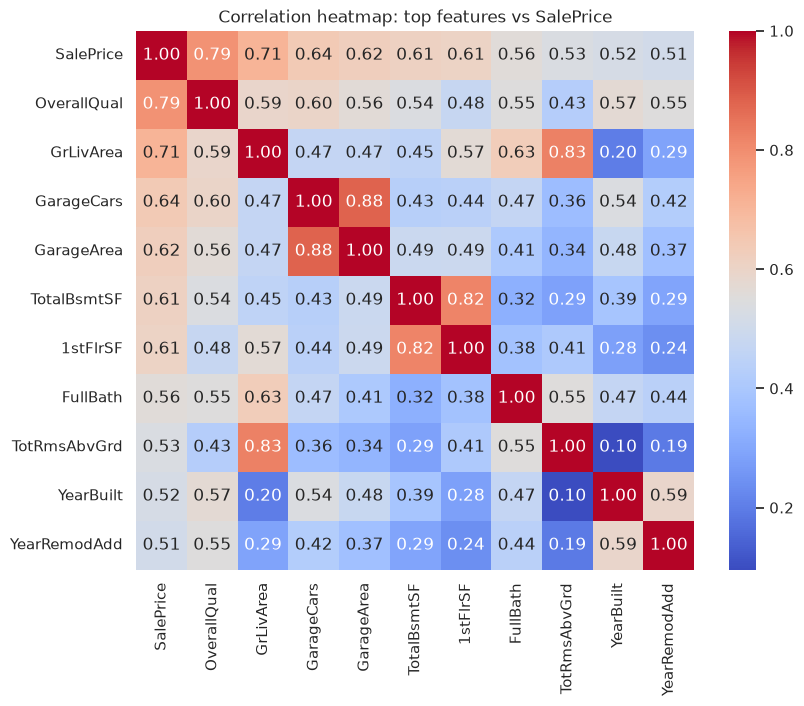

In [6]:
top_features = corr.index[1:11]  # skip SalePrice itself

plt.figure(figsize=(9, 7))
sns.heatmap(train[["SalePrice", *top_features]].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation heatmap: top features vs SalePrice")
plt.show()


`OverallQual` and `GrLivArea` stand out as the strongest linear predictors of `SalePrice`.
We'll start with `GrLivArea` for simple linear regression, then expand to multiple regression.

## 4. Simple linear regression: `GrLivArea` → `SalePrice`

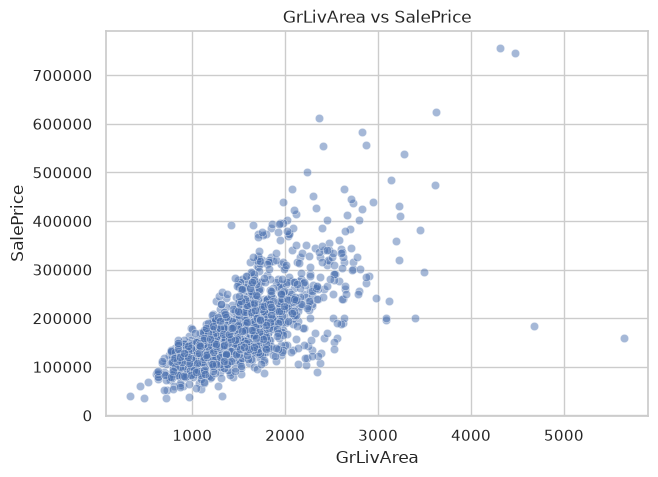

In [7]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=train, x="GrLivArea", y="SalePrice", alpha=0.5)
plt.title("GrLivArea vs SalePrice")
plt.show()


In [8]:
# Drop the two well-known large-area/low-price outliers (commonly flagged in this dataset)
train_clean = train[~((train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000))].copy()
print(f"Dropped {len(train) - len(train_clean)} outlier rows")


Dropped 2 outlier rows


In [9]:
X_simple = train_clean[["GrLivArea"]]
y = train_clean["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)

simple_model = LinearRegression()
simple_model.fit(X_train, y_train)

y_pred = simple_model.predict(X_test)

print(f"Coefficient (slope): {simple_model.coef_[0]:.2f}")
print(f"Intercept:           {simple_model.intercept_:.2f}")
print(f"RMSE:  {np.sqrt(mean_squared_error(y_test, y_pred)):.0f}")
print(f"R^2:   {r2_score(y_test, y_pred):.3f}")


Coefficient (slope): 118.61
Intercept:           1562.01
RMSE:  52993
R^2:   0.492


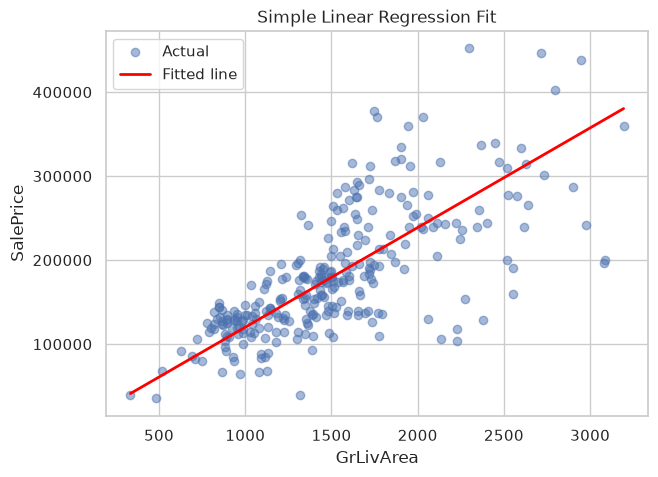

In [10]:
plt.figure(figsize=(7, 5))
plt.scatter(X_test, y_test, alpha=0.5, label="Actual")
order = X_test["GrLivArea"].argsort()
plt.plot(X_test["GrLivArea"].values[order], y_pred[order], color="red", linewidth=2, label="Fitted line")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("Simple Linear Regression Fit")
plt.legend()
plt.show()


Each additional square foot of living area is associated with roughly the coefficient above in extra sale price.
A single feature already explains a good chunk of the variance, but there's clear spread — other features matter too.

## 5. Multiple linear regression

In [11]:
features = [
    "OverallQual", "GrLivArea", "GarageCars", "GarageArea", "TotalBsmtSF",
    "1stFlrSF", "FullBath", "TotRmsAbvGrd", "YearBuilt", "YearRemodAdd",
]

df_model = train_clean[features + ["SalePrice"]].dropna()
X = df_model[features]
y = df_model["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

mlr = LinearRegression()
mlr.fit(X_train_scaled, y_train)

y_pred = mlr.predict(X_test_scaled)

print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.0f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.0f}")
print(f"R^2:  {r2_score(y_test, y_pred):.3f}")


RMSE: 31541
MAE:  23573
R^2:  0.820


/tmp/ipykernel_639633/3840676348.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x="coefficient", y="feature", palette="viridis")


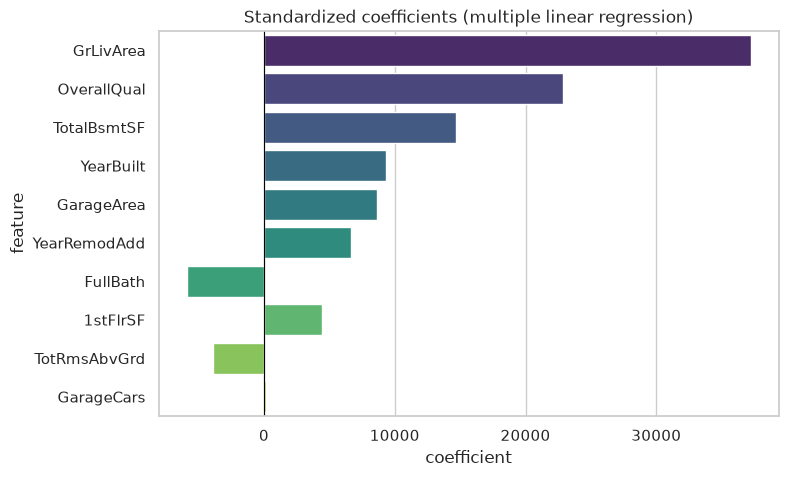

,feature,coefficient
1,GrLivArea,37209.315614
0,OverallQual,22833.642443
4,TotalBsmtSF,14647.652912
8,YearBuilt,9316.137988
3,GarageArea,8620.349180
9,YearRemodAdd,6647.351395
6,FullBath,-5888.279796
5,1stFlrSF,4420.494550
7,TotRmsAbvGrd,-3931.529114
2,GarageCars,177.478808


In [12]:
coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": mlr.coef_,
}).sort_values("coefficient", key=np.abs, ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=coef_df, x="coefficient", y="feature", palette="viridis")
plt.title("Standardized coefficients (multiple linear regression)")
plt.axvline(0, color="black", linewidth=0.8)
plt.show()

coef_df


Because features were standardized, coefficients are directly comparable — larger magnitude means a bigger
effect on `SalePrice` per standard deviation change. `OverallQual` and `GrLivArea` dominate, as expected from
the correlation analysis.

## 6. Residual diagnostics

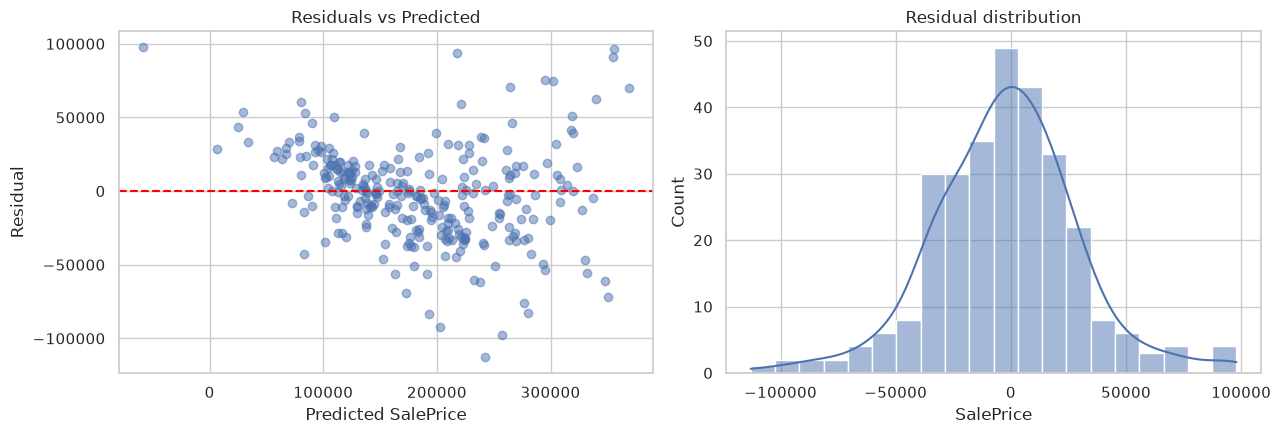

In [13]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(y_pred, residuals, alpha=0.5)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted SalePrice")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted")

sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title("Residual distribution")

plt.tight_layout()
plt.show()


The funnel shape in the residual plot (variance increasing with predicted price) suggests
heteroscedasticity — a common reason to model `log(SalePrice)` instead of the raw price.

## 7. Modeling `log(SalePrice)` instead

In [14]:
y_log = np.log1p(df_model["SalePrice"])

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LinearRegression()
log_model.fit(X_train_scaled, y_train_log)

y_pred_log = log_model.predict(X_test_scaled)

# back-transform to price scale for a fair RMSE comparison
y_pred_price = np.expm1(y_pred_log)
y_test_price = np.expm1(y_test_log)

print("On log scale:")
print(f"  R^2:  {r2_score(y_test_log, y_pred_log):.3f}")
print("On original price scale (back-transformed):")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test_price, y_pred_price)):.0f}")
print(f"  R^2:  {r2_score(y_test_price, y_pred_price):.3f}")


On log scale:
  R^2:  0.846
On original price scale (back-transformed):
  RMSE: 26930
  R^2:  0.869


## 8. Regularized regression: Ridge & Lasso

In [15]:
ridge = Ridge(alpha=10)
ridge.fit(X_train_scaled, y_train_log)
ridge_pred = np.expm1(ridge.predict(X_test_scaled))

lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train_log)
lasso_pred = np.expm1(lasso.predict(X_test_scaled))

results = pd.DataFrame({
    "model": ["Linear (log target)", "Ridge (log target)", "Lasso (log target)"],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test_price, y_pred_price)),
        np.sqrt(mean_squared_error(y_test_price, ridge_pred)),
        np.sqrt(mean_squared_error(y_test_price, lasso_pred)),
    ],
    "R2": [
        r2_score(y_test_price, y_pred_price),
        r2_score(y_test_price, ridge_pred),
        r2_score(y_test_price, lasso_pred),
    ],
})
results


,model,RMSE,R2
0,Linear (log target),26930.136796,0.868706
1,Ridge (log target),26960.189741,0.868413
2,Lasso (log target),27247.042078,0.865598


Ridge and Lasso add an L2/L1 penalty on the coefficients, which helps when features are correlated
(e.g. `GarageCars` and `GarageArea`) by shrinking redundant coefficients toward zero. With only 10 features
the gain over plain linear regression is usually modest — regularization matters more as feature count grows.

## 9. Summary

- `GrLivArea` alone explains a meaningful share of `SalePrice` variance, confirming a strong linear relationship.
- Adding more features (`OverallQual`, `GarageCars`, `TotalBsmtSF`, etc.) substantially improves fit.
- `SalePrice` is right-skewed and residuals are heteroscedastic on the raw scale; modeling `log(SalePrice)`
  produces more stable residuals and is standard practice for this dataset.
- Ridge/Lasso regularization gives comparable or slightly better generalization by controlling for
  multicollinearity among correlated features.

**Next steps:** encode categorical features (e.g. `Neighborhood`, `KitchenQual`), engineer features (total
square footage, house age), and try cross-validated hyperparameter search for `alpha`.
